# Chronos-2 Quality Net — Results, prediction_length=4, context_length=1536 (2026-08-21)

`train/finetune_chronos2.py --prediction-length 4 --context-length 1536`, `eval/backtest.py
--context-length 1536`로 실행한 결과입니다. `results_loss_curves.ipynb`에서 512/768/1024가 계속
좋아지는 학습(val) loss 추세를 보고 한 단계 더 늘려본 지점이고(residue는 계속 개선, blaine은 여기서
불안정해짐), 이 노트북은 그 체크포인트로 실제 백테스트(MAE/RMSE/R²/spec 정확도)를 돌린 결과입니다.
`results_context1280.ipynb`와 나란히 비교하면 됩니다.

이 노트북은 GPU를 다시 쓰지 않습니다 — `eval/backtest_*_predlen4_ctx1536_*_v2.csv` /
`eval/backtest_*_predlen4_ctx1536_zeroshot.csv` 결과 파일만 읽습니다. `eval/backtest.py`의 `predict_df`
호출은 여전히 `prediction_length=1`로 하드코딩되어 있어(평가 방식은 다른 `results_context*.ipynb`와
동일), 학습 시 held-out 구간(4)과 평가 시 예측 구간(1)이 다른 것은 의도된 설계입니다 — 자세한 이유는
`results_context512.ipynb` 및 `EXPERIMENT_LOG.md` 참고.

비교 대상 4가지:
- **Naive baseline**: 직전 실측값을 그대로 예측값으로 사용
- **Zero-shot**: `amazon/chronos-2` 사전학습 가중치, 파인튜닝 없음, `--context-length 1536`으로 평가
- **LoRA**: `--prediction-length 4 --context-length 1536`로 학습 (`checkpoints/{target}_predlen4_ctx1536_lora_v2/final`)
- **Full fine-tuning**: `--prediction-length 4 --context-length 1536`, `learning_rate=1e-6`
  (`checkpoints/{target}_full_predlen4_ctx1536_v2/final`)


In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 한글 폰트
matplotlib.rcParams['axes.unicode_minus'] = False

ROOT = Path.cwd()
if not (ROOT / "config.py").exists():
    raise RuntimeError(
        f"config.py를 {ROOT} 에서 찾지 못했습니다. Jupyter를 chronos_quality_net 폴더에서 실행하거나, "
        "이 노트북을 그 폴더로 옮겨서 다시 여세요."
    )
sys.path.insert(0, str(ROOT))
import config as cfg

TARGETS = cfg.TARGET_COLS  # ["blaine", "residue"]
print("targets:", TARGETS)
print("spec ranges:", cfg.SPEC_RANGES)

METHOD_TAGS = {
    "zero-shot": "predlen4_ctx1536_zeroshot",
    "LoRA": "predlen4_ctx1536_lora_v2",
    "Full fine-tuning": "predlen4_ctx1536_full_v2",
}
METHODS = list(METHOD_TAGS.keys())

targets: ['blaine', 'residue']
spec ranges: {'blaine': (3700.0, 3900.0), 'residue': (7.0, 9.0)}


## 1. 결과 파일 불러오기

In [2]:
EVAL_DIR = ROOT / "eval"

results = {}
for target in TARGETS:
    results[target] = {}
    for method, tag in METHOD_TAGS.items():
        p = EVAL_DIR / f"backtest_{target}_{tag}.csv"
        if p.exists():
            results[target][method] = pd.read_csv(p, parse_dates=["timestamp"])
        else:
            print(f"[missing] {p}")

for target in TARGETS:
    for method in METHODS:
        df = results[target].get(method)
        print(target, method, "->", None if df is None else f"{len(df)} rows")

blaine zero-shot -> 1007 rows
blaine LoRA -> 1007 rows
blaine Full fine-tuning -> 1007 rows
residue zero-shot -> 979 rows
residue LoRA -> 979 rows
residue Full fine-tuning -> 979 rows


## 2. 요약 지표 (MAE / RMSE / R² / Spec 정확도 / 80% 구간 커버리지)

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix


def categorize(values, lo, hi):
    return np.where((values >= lo) & (values <= hi), "IN_SPEC", "OUT_OF_SPEC")


def compute_metrics(df: pd.DataFrame, target: str, pred_col: str) -> dict:
    lo, hi = cfg.SPEC_RANGES[target]
    mae = mean_absolute_error(df["actual"], df[pred_col])
    rmse = np.sqrt(mean_squared_error(df["actual"], df[pred_col]))
    r2 = r2_score(df["actual"], df[pred_col])
    actual_cls = categorize(df["actual"].to_numpy(), lo, hi)
    pred_cls = categorize(df[pred_col].to_numpy(), lo, hi)
    spec_accuracy = float((actual_cls == pred_cls).mean())
    row = {"MAE": mae, "RMSE": rmse, "R2": r2, "spec_accuracy": spec_accuracy, "n": len(df)}
    if pred_col == "pred" and "pred_q10" in df.columns and "pred_q90" in df.columns:
        row["interval_coverage"] = float(
            ((df["actual"] >= df["pred_q10"]) & (df["actual"] <= df["pred_q90"])).mean()
        )
    else:
        row["interval_coverage"] = np.nan
    return row


rows = []
for target in TARGETS:
    first_df = next((df for df in results[target].values() if df is not None), None)
    if first_df is not None:
        rows.append({"target": target, "method": "naive", **compute_metrics(first_df, target, "naive_pred")})
    for method in METHODS:
        df = results[target].get(method)
        if df is not None:
            rows.append({"target": target, "method": method, **compute_metrics(df, target, "pred")})

summary = pd.DataFrame(rows).set_index(["target", "method"])
summary.round(4)

MAE     RMSE      R2  spec_accuracy     n  \
target  method                                                            
blaine  naive             63.2075  92.9357  0.3908         0.7259  1007   
        zero-shot         64.9770  88.3173  0.4499         0.7150  1007   
        LoRA              64.7912  87.9142  0.4549         0.7160  1007   
        Full fine-tuning  64.1315  86.4349  0.4731         0.7259  1007   
residue naive              0.4150   0.6203  0.8091         0.8131   979   
        zero-shot          0.4283   0.5915  0.8265         0.8008   979   
        LoRA               0.4263   0.5850  0.8303         0.8080   979   
        Full fine-tuning   0.4212   0.5716  0.8380         0.8100   979   

                          interval_coverage  
target  method                               
blaine  naive                           NaN  
        zero-shot                    0.3962  
        LoRA                         0.4111  
        Full fine-tuning             0.4052  
residue naive                           NaN  
        zero-shot                    0.3933  
        LoRA                         0.4157  
        Full fine-tuning             0.5138

## 3. 방식별 비교 막대그래프 (MAE, RMSE, Spec 정확도)

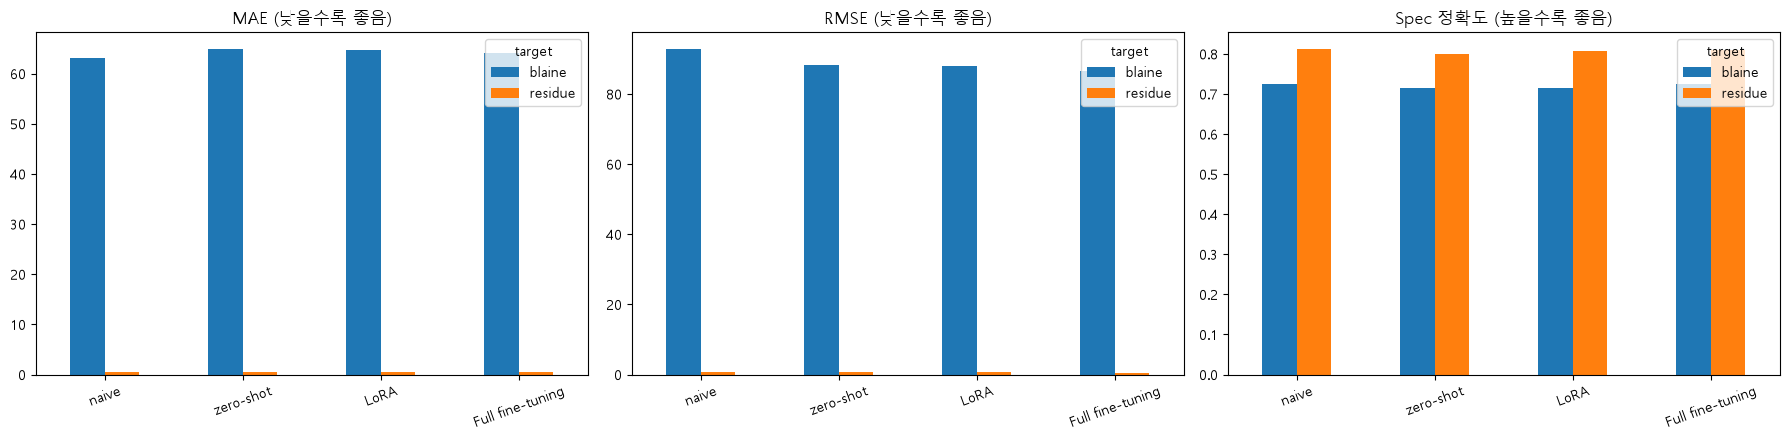

In [4]:
method_order = ["naive"] + METHODS
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

metrics = ["MAE", "RMSE", "spec_accuracy"]
titles = ["MAE (낮을수록 좋음)", "RMSE (낮을수록 좋음)", "Spec 정확도 (높을수록 좋음)"]
for ax, metric, title in zip(axes, metrics, titles):
    plot_df = summary[metric].unstack("target").reindex(method_order)
    plot_df.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.legend(title="target")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 4. 실제값 vs 예측값 산점도 (naive / zero-shot / LoRA / full)

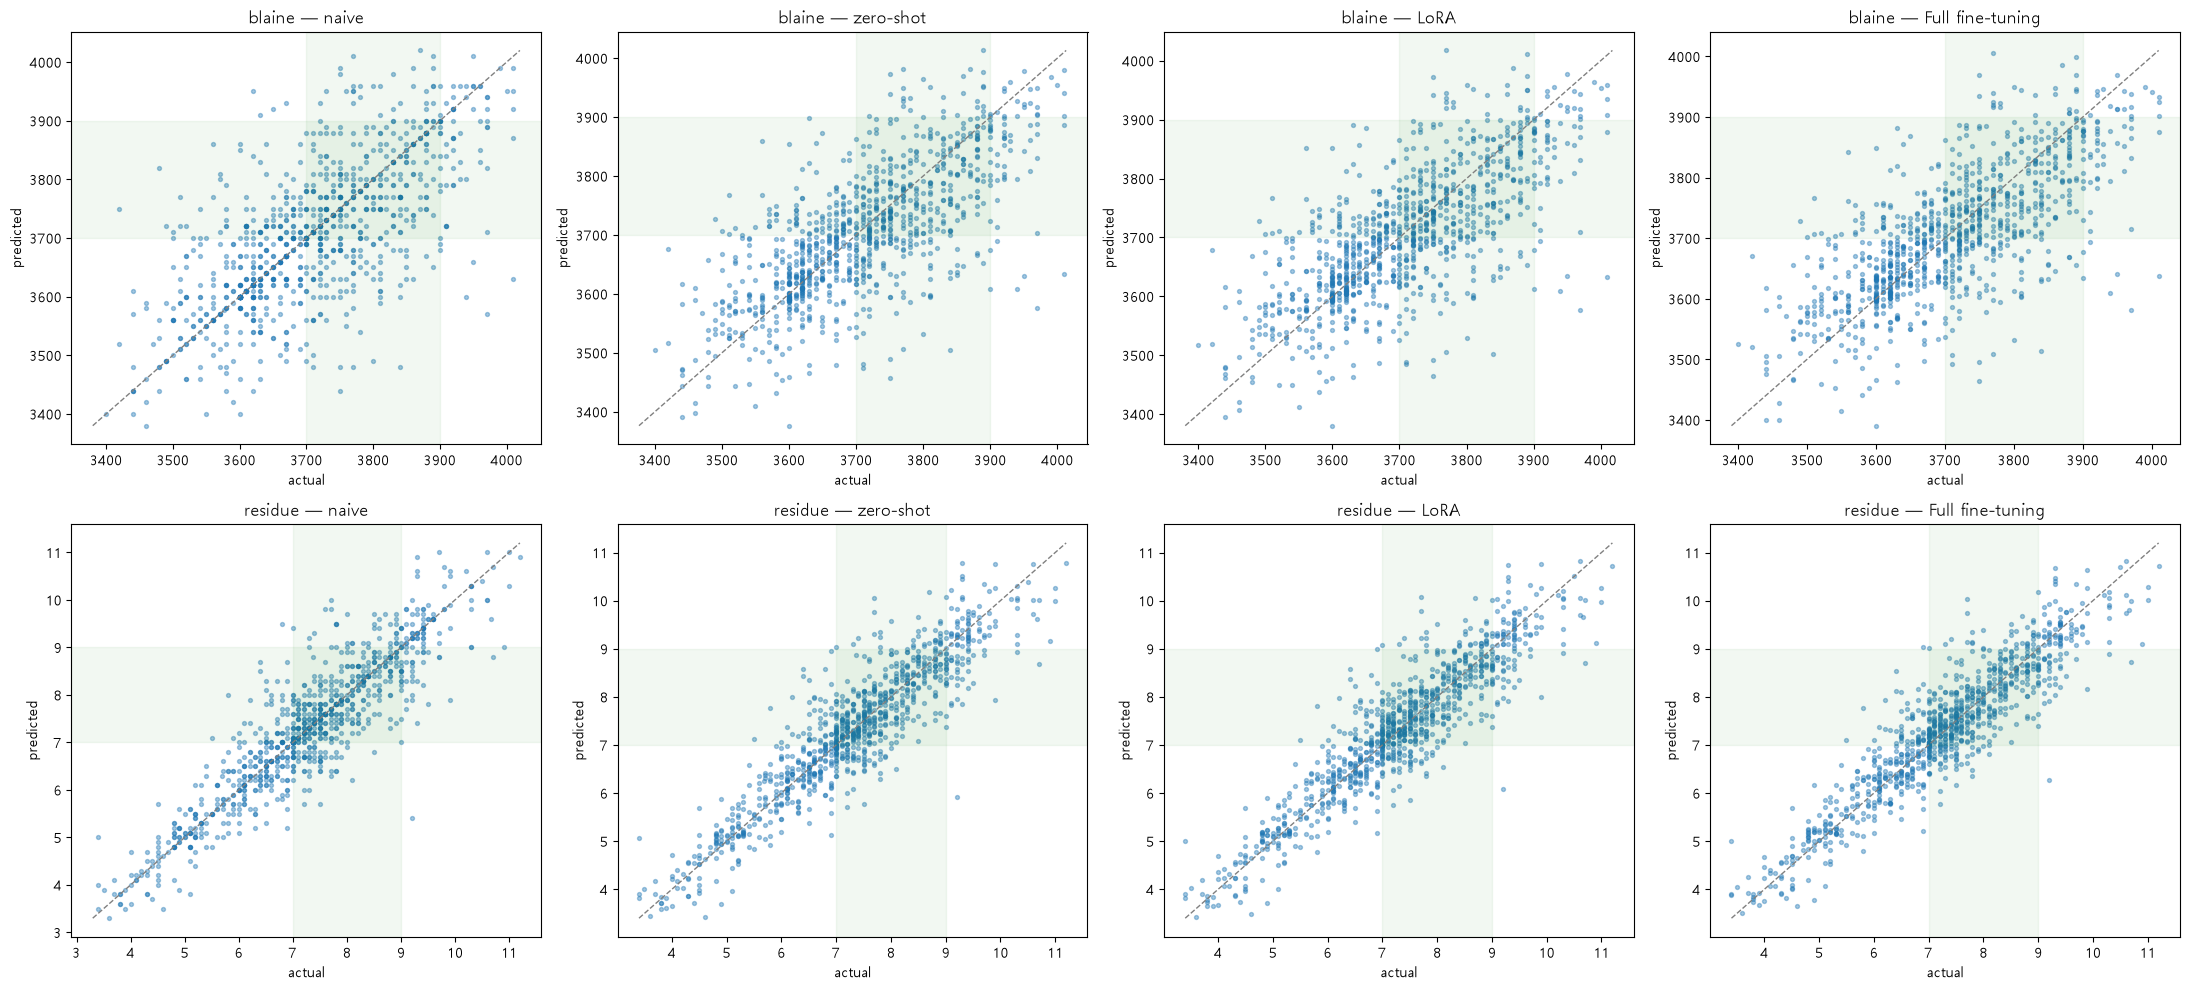

In [5]:
fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(5.5 * (1 + len(METHODS)), 5 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        ax.scatter(df["actual"], df[pred_col], s=8, alpha=0.4)
        lims = [min(df["actual"].min(), df[pred_col].min()), max(df["actual"].max(), df[pred_col].max())]
        ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1)
        ax.axvspan(lo, hi, color="green", alpha=0.05)
        ax.axhspan(lo, hi, color="green", alpha=0.05)
        ax.set_title(f"{target} — {label}")
        ax.set_xlabel("actual")
        ax.set_ylabel("predicted")

plt.tight_layout()
plt.show()

## 5. 시계열: 실제값 vs 예측 + 80% 예측구간 (full fine-tuning 모델, 호기별)

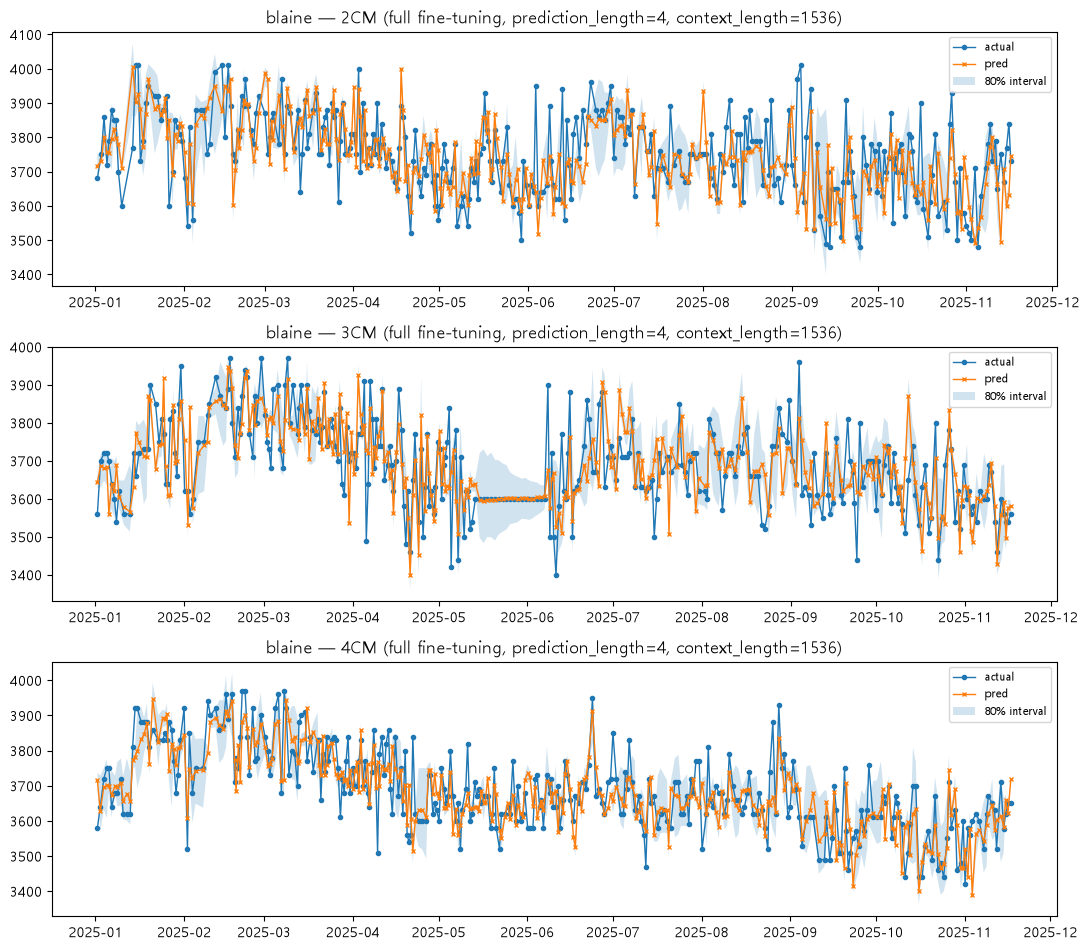

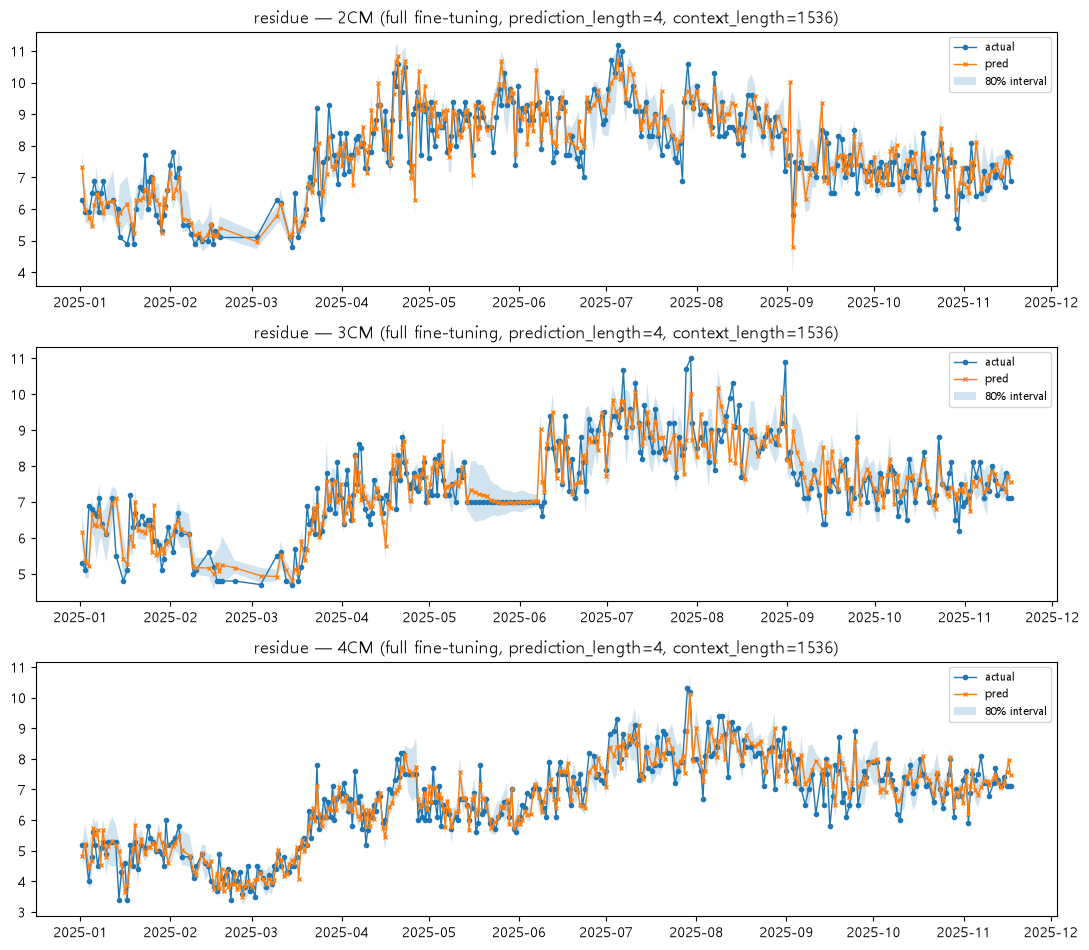

In [6]:
for target in TARGETS:
    df = results[target].get("Full fine-tuning")
    if df is None:
        continue
    item_ids = sorted(df["item_id"].unique())
    fig, axes = plt.subplots(len(item_ids), 1, figsize=(11, 3.2 * len(item_ids)), sharex=False)
    if len(item_ids) == 1:
        axes = [axes]
    for ax, item_id in zip(axes, item_ids):
        g = df[df["item_id"] == item_id].sort_values("timestamp")
        ax.plot(g["timestamp"], g["actual"], label="actual", marker="o", markersize=3, linewidth=1)
        ax.plot(g["timestamp"], g["pred"], label="pred", marker="x", markersize=3, linewidth=1)
        ax.fill_between(g["timestamp"], g["pred_q10"], g["pred_q90"], alpha=0.2, label="80% interval")
        ax.set_title(f"{target} — {item_id} (full fine-tuning, prediction_length=4, context_length=1536)")
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

## 6. Confusion Matrix (Spec-in / Spec-out)

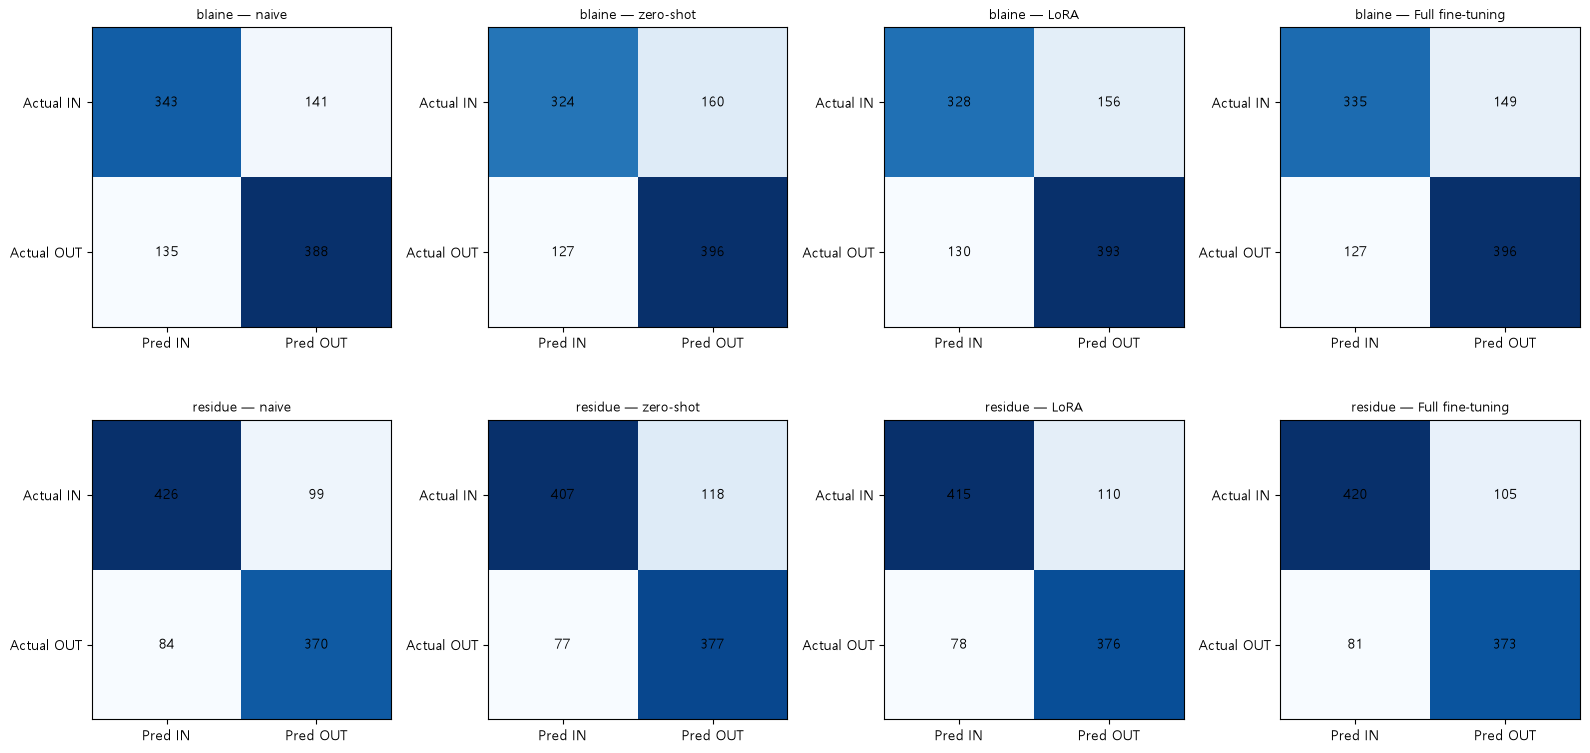

In [7]:
def plot_cm(ax, actual, pred, lo, hi, title):
    actual_cls = categorize(actual, lo, hi)
    pred_cls = categorize(pred, lo, hi)
    cm = confusion_matrix(actual_cls, pred_cls, labels=["IN_SPEC", "OUT_OF_SPEC"])
    ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred IN", "Pred OUT"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual IN", "Actual OUT"])
    ax.set_title(title, fontsize=9)


fig, axes = plt.subplots(len(TARGETS), 1 + len(METHODS), figsize=(4 * (1 + len(METHODS)), 4 * len(TARGETS)))
if len(TARGETS) == 1:
    axes = axes[None, :]

for row, target in enumerate(TARGETS):
    lo, hi = cfg.SPEC_RANGES[target]
    first_df = next((df for df in results[target].values() if df is not None), None)
    cols = [("naive", "naive_pred", first_df)] + [(m, "pred", results[target].get(m)) for m in METHODS]
    for col_idx, (label, pred_col, df) in enumerate(cols):
        ax = axes[row, col_idx]
        if df is None:
            ax.set_visible(False)
            continue
        plot_cm(ax, df["actual"].to_numpy(), df[pred_col].to_numpy(), lo, hi, f"{target} — {label}")

plt.tight_layout()
plt.show()

## 7. 결론

**Full fine-tuning 기준, 1024/1280과 비교:**

| target | ctx1024 MAE | ctx1280 MAE | ctx1536 MAE | ctx1024 R² | ctx1536 R² |
|---|---|---|---|---|---|
| blaine | 63.52 | 63.86 | **64.13(최악)** | 0.4803 | 0.4731 |
| residue | 0.4238 | 0.4235 | **0.4212(최선)** | 0.8345 | 0.8380 |

- **residue는 1536이 지금까지(512~1536) 중 MAE/R² 둘 다 최고**입니다 — `results_loss_curves.ipynb`의
  학습 loss 추세(계속 개선)와 방향이 일치합니다.
- **blaine은 1536이 오히려 1024/1280보다 더 나쁩니다**(MAE 64.13, 세 지점 중 최악) —
  `results_loss_curves.ipynb`에서 이미 확인했던 "blaine은 1536에서 학습이 불안정해진다"(최저점이
  step 100에서만 나오고 이후 못 돌아옴)는 관찰이 **백테스트 MAE로도 그대로 이어졌습니다.** 즉 이번
  1536은 loss 곡선과 백테스트 결과가 (blaine 기준) 같은 방향으로 나빠진, 앞선 1280과는 다른 케이스입니다.
- spec 정확도는 blaine이 72.59%로 오히려 셋 중 가장 높습니다(1024: 71.30%, 1280: 71.90%) — MAE/R²와
  spec 정확도가 서로 다른 방향을 가리키는 패턴이 1280에 이어 여기서도 반복됩니다.
- 80% 구간 커버리지는 residue Full이 51.38%로 여전히 목표(80%)엔 못 미치지만 계속 개선 추세를
  유지합니다. blaine은 40.52%로 1280(46.77%)보다 오히려 하락 — 이 지표에서도 blaine만 1536에서
  꺾입니다.

**종합**: **blaine 기준 context_length의 실전 최적값은 1280**입니다 — 1536은 학습 loss도
불안정했고, 지금 백테스트 MAE/커버리지에서도 확인상 더 나쁩니다. **residue는 1536까지 일관되게
계속 좋아지고 있어서, 더 큰 context_length(예: 2048)를 시도해볼 여지가 residue엔 남아있습니다** —
다만 2048은 이 GPU(8.5GB)에서 step당 시간이 1024 대비 ~8배로 튀어서 아직 정식 학습은 안 했습니다
(`results_loss_curves.ipynb` 참고). 두 타깃이 서로 다른 최적 context_length를 가질 수 있다는 것도
이번 스윕에서 새로 드러난 점입니다.